In [46]:
import argparse
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

In [47]:
def load_ktau_file(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data


def extract_ktaus(data):
    # find keys that end with '_ktaus'
    ktau_keys = [k for k in data.keys() if k.endswith('_ktaus')]
    extracted = {}
    for k in ktau_keys:
        # each is a dict with entries like 'all', 'high_return', ... each a (num_tasks, num_runs) array
        extracted[k] = data[k]
    return extracted

def mean_across_runs(arr):
    # arr shape (num_tasks, num_runs)
    return np.mean(arr, axis=1)


In [48]:
def plot_per_task(all_means, all_stds, labels, comparison):
    # all_means: list of arrays (num_tasks,)
    # all_stds: list of arrays (num_tasks,)
    plt.figure(figsize=(10, 5))
    num_tasks = all_means[0].shape[0]
    x = np.arange(1,num_tasks+1)
    plt.xticks(x, [str(int(i)) for i in x])
    for mean_arr, std_arr, label in zip(all_means, all_stds, labels):
        plt.errorbar(x, mean_arr, yerr=std_arr, marker='o', capsize=5, label=label, linestyle='-')
    plt.xlabel('Task id', fontdict={'size': 18})
    plt.ylabel('Kendall tau (mean over runs)', fontdict={'size': 18})
    plt.title(f'{comparison} — per-task mean Kendall tau across budgets (± std across runs)', fontdict={'size': 20})
    plt.legend(fontsize=18)
    plt.grid(alpha=0.25)
    # display inline instead of saving to file
    plt.tight_layout()
    plt.show()


In [49]:
def plot_bar_avg(all_means, labels, comparison):
    # all_means: list of arrays (num_tasks,) where each array is mean_per_task for a budget
    # compute average across tasks for each budget and the std across tasks for error bars
    avgs = [arr.mean() for arr in all_means]
    stds = [arr.std(ddof=0) for arr in all_means]

    plt.figure(figsize=(8, 4))
    x = np.arange(len(labels))
    plt.bar(x, avgs, yerr=stds, capsize=6, tick_label=labels, color='C0', alpha=0.9)
    plt.ylabel('Mean Kendall tau (avg over tasks and runs)')
    plt.title(f'{comparison} — average Kendall tau across budgets (± std across tasks)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [50]:
# # base_dir_template = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/align_runs-10-new-thresholds/bg_{bg}/eh_step_0.0005/reg_beta_0.3/noise_[0.0, 0.6, 1.0]_neg_[0.6]/half-cheetah_ep600"
# base_dir_template = "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/HalfCheetah-v4/HYPER/align_runs-10-v3/bg_{bg}/eh_step_0.0005/reg_beta_0.3/noise_[0.0, 0.6, 1.0]_neg_[0.6]/half-cheetah_ep600"

# ktau_filename = "HYPER_HalfCheetah-v4_ktau.pkl"
# budgets = [500, 1500, 2500, 3500]

# all_files = []
# labels = []
# missing = []
# for bg in budgets:
#     candidate = os.path.join(base_dir_template.format(bg=bg), ktau_filename)
#     if os.path.isfile(candidate):
#         all_files.append(candidate)
#         labels.append(f"bg_{bg}")
#     else:
#         missing.append(candidate)

# if len(missing) > 0:
#     print("Warning: some ktau files were not found:")
#     for m in missing:
#         print("  ", m)

# print(f"Using {len(all_files)} ktau files:")
# for l, f in zip(labels, all_files):
#     print(l, f)

In [51]:
# Replace the paths below with the full paths to each baseline's ktau pickle file.
# Expecting full filenames (e.g. "/.../HYPER_HalfCheetah-v4_ktau.pkl")

env = "MW-Seq-4"

if env == "MW-Seq-2":
    baseline_files = {
        "HYPER":          "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/HYPER/align_runs-10-test/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/HYPER_MW-Seq-2_ktau.pkl",
        "SI-0.1":         "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/align_runs-10-test/beta_0.1/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/SI_MW-Seq-2_ktau.pkl",
        "SI-1.0":         "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/align_runs-10-test/beta_1.0/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/SI_MW-Seq-2_ktau.pkl",
        "SI-10.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/SI/align_runs-10-test/beta_10.0/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/SI_MW-Seq-2_ktau.pkl",
        "Scratch":       "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/LFS_HNET/align_runs-10-test/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/LFS_HNET_MW-Seq-2_ktau.pkl",
        "DGR-1.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/align_runs-10-test/lambda_vae_1.0/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/DGR_MW-Seq-2_ktau.pkl",
        "DGR-5.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-2/DGR/align_runs-10-test/lambda_vae_5.0/noise_[0.0, 0.95, 1.0]_neg_[0.6]/MW-Seq-2_ep600/DGR_MW-Seq-2_ktau.pkl",
        # "LFS_HNET":   "/path/to/LFS_HNET/LFS_HNET_HalfCheetah-v4_ktau.pkl",
    }
elif env == "MW-Seq-4":
    baseline_files = {
        "HYPER":          "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/HYPER/align_runs-10-test/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/HYPER_MW-Seq-4_ktau.pkl",
        "SI-0.1":         "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_0.1/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl",
        "SI-1.0":         "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_1.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl",
        "SI-10.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_10.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl",
        "Scratch":       "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/LFS_HNET/align_runs-10-test/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/LFS_HNET_MW-Seq-4_ktau.pkl",
        "DGR-1.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/DGR/align_runs-10-test/lambda_vae_1.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/DGR_MW-Seq-4_ktau.pkl",
        "DGR-5.0":        "/Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/DGR/align_runs-10-test/lambda_vae_5.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/DGR_MW-Seq-4_ktau.pkl",

    }
all_files = []
labels = []
missing = []
for lbl, p in baseline_files.items():
    if os.path.isfile(p):
        all_files.append(p)
        labels.append(lbl)
    else:
        missing.append((lbl, p))

if missing:
    print("Warning: some ktau files were not found:")
    for lbl, p in missing:
        print("  ", lbl, p)

print(f"Using {len(all_files)} ktau files:")
for l, f in zip(labels, all_files):
    print(l, f)

Using 7 ktau files:
HYPER /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/HYPER/align_runs-10-test/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/HYPER_MW-Seq-4_ktau.pkl
SI-0.1 /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_0.1/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl
SI-1.0 /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_1.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl
SI-10.0 /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/SI/align_runs-10-test/beta_10.0/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/SI_MW-Seq-4_ktau.pkl
Scratch /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/LFS_HNET/align_runs-10-test/noise_[0.0, 0.85, 1.0]_neg_[0.6]/MW-Seq-4_ep600/LFS_HNET_MW-Seq-4_ktau.pkl
DGR-1.0 /Users/sooraj/personal/Pre-Doc/Matt-Srijita/Code/results/MW-Seq-4/DGR/align_runs-10-test/lambda_vae_1.0/n

In [52]:
# Build per-file extracted ktaus and the comparison keys
per_file_ktaus = []
for p in all_files:
    data = load_ktau_file(p)
    extracted = extract_ktaus(data)
    per_file_ktaus.append(extracted)

# gather all comparison keys across files
comparison_keys = set()
for d in per_file_ktaus:
    comparison_keys.update(d.keys())
comparison_keys = sorted(list(comparison_keys))






In [53]:
def plot_align(type):
    # Iterate and plot for each comparison key

    for comp in comparison_keys:
        if comp == "task_final_ktaus":
            continue  # skip this one for now
        
    # collect 'all' arrays for this comp across files (skip file if missing comp)
        all_arrs = []
        all_stds = []
        valid_labels = []
        for lbl, d in zip(labels, per_file_ktaus):
            # print(d[comp].keys())
            if comp in d and type in d[comp]:
                arr = np.array(d[comp][type])  # shape (num_tasks, num_runs)
                mean_per_task = mean_across_runs(arr)  # shape (num_tasks,)
                std_per_task = np.std(arr, axis=1)  # std across runs for each task
                all_arrs.append(mean_per_task)
                all_stds.append(std_per_task)
                valid_labels.append(lbl)
        if len(all_arrs) == 0:
            continue
        # Plot per-task lines with error bars per task
        plot_per_task(all_arrs, all_stds, valid_labels, comp)
        # Plot bar of averages with std across tasks
        # plot_bar_avg(all_arrs, valid_labels, comp)

    print('Done')

####Plotting for type: all####


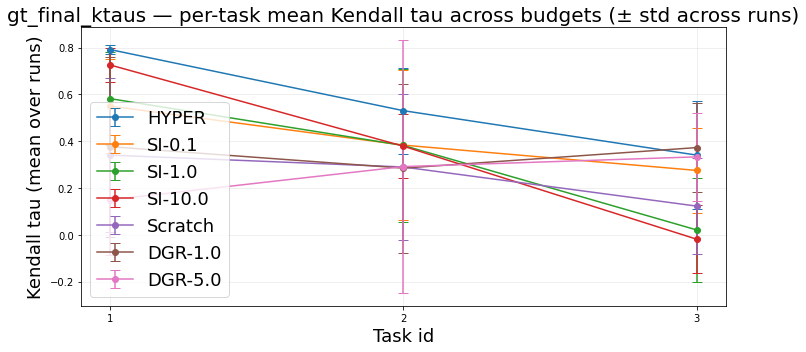

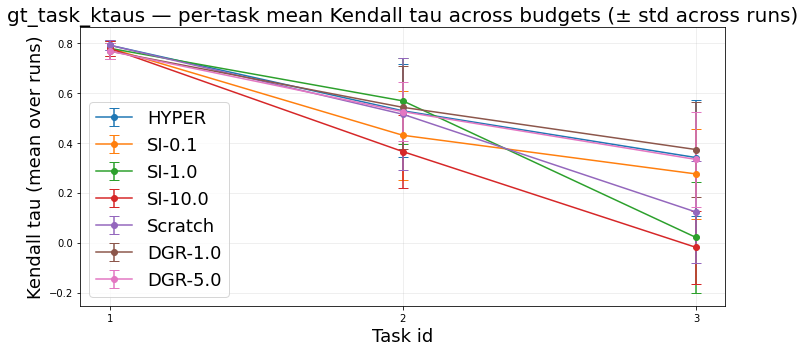

Done


In [54]:
for type in ['all', 'high_return', 'mid_return', 'low_return', 'high_mid_return', 'mid_low_return', 'low_high_return']:
    # if not type == "high_mid_return":
    #     continue
    if not type =="all":
        continue
    print(f"####Plotting for type: {type}####")
    plot_align(type)

In [55]:
# # create an images directory and save plots instead of showing them
# images_dir = "images"
# os.makedirs(images_dir, exist_ok=True)

# def _safe_fname(s: str) -> str:
#     return "".join(c if c.isalnum() or c in "-._" else "_" for c in s)

# def save_plot_per_task(all_means, all_stds, labels, comparison, out_path):
#     plt.figure(figsize=(10, 5))
#     num_tasks = all_means[0].shape[0]
#     x = np.arange(num_tasks)
#     for mean_arr, std_arr, label in zip(all_means, all_stds, labels):
#         plt.errorbar(x, mean_arr, yerr=std_arr, marker='o', capsize=5, label=label, linestyle='-')
#     plt.xlabel('Task id')
#     plt.ylabel('Kendall tau (mean over runs)')
#     plt.title(f'{comparison} — per-task mean Kendall tau across budgets (± std across runs)')
#     plt.legend()
#     plt.grid(alpha=0.25)
#     plt.tight_layout()
#     plt.savefig(out_path, dpi=200)
#     plt.close()

# def save_plot_bar_avg(all_means, labels, comparison, out_path):
#     avgs = [arr.mean() for arr in all_means]
#     stds = [arr.std(ddof=0) for arr in all_means]

#     plt.figure(figsize=(8, 4))
#     x = np.arange(len(labels))
#     plt.bar(x, avgs, yerr=stds, capsize=6, tick_label=labels, color='C0', alpha=0.9)
#     plt.ylabel('Mean Kendall tau (avg over tasks and runs)')
#     plt.title(f'{comparison} — average Kendall tau across budgets (± std across tasks)')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.savefig(out_path, dpi=200)
#     plt.close()

# def save_align_plots(type):
#     saved = []
#     for comp in comparison_keys:
#         if comp == "task_final_ktaus":
#             continue

#         all_arrs = []
#         all_stds = []
#         valid_labels = []
#         for lbl, d in zip(labels, per_file_ktaus):
#             if comp in d and type in d[comp]:
#                 arr = np.array(d[comp][type])  # shape (num_tasks, num_runs)
#                 mean_per_task = mean_across_runs(arr)  # shape (num_tasks,)
#                 std_per_task = np.std(arr, axis=1)
#                 all_arrs.append(mean_per_task)
#                 all_stds.append(std_per_task)
#                 valid_labels.append(lbl)
#         if len(all_arrs) == 0:
#             continue

#         comp_safe = _safe_fname(comp)
#         type_safe = _safe_fname(type)
#         per_task_fname = f"{comp_safe}__{type_safe}__per_task.png"
#         avg_fname = f"{comp_safe}__{type_safe}__avg.png"

#         per_task_path = os.path.join(images_dir, per_task_fname)
#         avg_path = os.path.join(images_dir, avg_fname)

#         save_plot_per_task(all_arrs, all_stds, valid_labels, comp, per_task_path)
#         save_plot_bar_avg(all_arrs, valid_labels, comp, avg_path)

#         saved.append((per_task_path, avg_path))

#     return saved

# # run and save for all types
# all_saved = {}
# for typ in ['all', 'high_return', 'mid_return', 'low_return', 'high_mid_return', 'mid_low_return', 'low_high_return']:
#     saved_files = save_align_plots(typ)
#     if saved_files:
#         all_saved[typ] = saved_files

# # print summary
# print(f"Saved images to '{images_dir}':")
# for typ, files in all_saved.items():
#     for per_task_path, avg_path in files:
#         print(" ", per_task_path)
#         print(" ", avg_path)

In [56]:
# plot, for each budget/file (label), one figure per comparison key
# where each figure contains lines for all types ('all', 'high_return', etc.)
def plot_per_budget():
    types = ['all', 'high_return', 'mid_return', 'low_return',
             'high_mid_return', 'mid_low_return', 'low_high_return']

    for lbl, d in zip(labels, per_file_ktaus):
        for comp in comparison_keys:
            if comp == "task_final_ktaus":
                continue

            means_list = []
            stds_list = []
            present_types = []
            for typ in types:
                if comp in d and typ in d[comp]:
                    arr = np.array(d[comp][typ])  # (num_tasks, num_runs)
                    mean_per_task = mean_across_runs(arr)  # (num_tasks,)
                    std_per_task = np.std(arr, axis=1)
                    means_list.append(mean_per_task)
                    stds_list.append(std_per_task)
                    present_types.append(typ)

            if len(means_list) == 0:
                continue

            plt.figure(figsize=(10, 5))
            num_tasks = means_list[0].shape[0]
            x = np.arange(num_tasks)
            for mean_arr, std_arr, typ in zip(means_list, stds_list, present_types):
                plt.errorbar(x, mean_arr, yerr=std_arr, marker='o', capsize=4, label=typ, linestyle='-')
            plt.xlabel('Task id')
            plt.ylabel('Kendall tau (mean over runs)')
            plt.title(f'{lbl} — {comp} (per-task, lines for each type)')
            plt.legend()
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()

# Run the plotting function
plot_per_budget()

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
from collections import defaultdict

types = ['all', 'high_return', 'mid_return', 'low_return',
         'high_mid_return', 'mid_low_return', 'low_high_return']

totals = defaultdict(int)           # total datapoints (num_tasks * num_runs) per type
arrays_found = defaultdict(int)     # how many arrays (comp/file pairs) contained this type
per_file_counts = defaultdict(lambda: defaultdict(int))
per_comp_counts = defaultdict(lambda: defaultdict(int))

for lbl, d in zip(labels, per_file_ktaus):
    for comp, compdict in d.items():
        if not isinstance(compdict, dict):
            continue
        for t in types:
            if t in compdict:
                arr = np.array(compdict[t])
                n = arr.size
                totals[t] += n
                arrays_found[t] += 1
                per_file_counts[lbl][t] += n
                per_comp_counts[comp][t] += n

print("Summary of datapoints per type (total elements = num_tasks * num_runs):")
for t in types:
    print(f" - {t}: arrays_found={arrays_found[t]:3d}, total_datapoints={totals[t]:6d}")

print("\nPer-file breakdown (types with non-zero datapoints):")
for lbl in labels:
    parts = [f"{t}={per_file_counts[lbl][t]}" for t in types if per_file_counts[lbl][t]]
    if parts:
        print(f" {lbl}: " + ", ".join(parts))

print("\nPer-comparison-key breakdown (types with non-zero datapoints):")
for comp in sorted(per_comp_counts.keys()):
    parts = [f"{t}={per_comp_counts[comp][t]}" for t in types if per_comp_counts[comp][t]]
    if parts:
        print(f" {comp}: " + ", ".join(parts))

Summary of datapoints per type (total elements = num_tasks * num_runs):
 - all: arrays_found= 15, total_datapoints=   378
 - high_return: arrays_found= 15, total_datapoints=   378
 - mid_return: arrays_found= 15, total_datapoints=   378
 - low_return: arrays_found= 15, total_datapoints=   378
 - high_mid_return: arrays_found= 15, total_datapoints=   378
 - mid_low_return: arrays_found= 15, total_datapoints=   378
 - low_high_return: arrays_found= 15, total_datapoints=   378

Per-file breakdown (types with non-zero datapoints):
 HYPER: all=18, high_return=18, mid_return=18, low_return=18, high_mid_return=18, mid_low_return=18, low_high_return=18
 SI-0.1: all=90, high_return=90, mid_return=90, low_return=90, high_mid_return=90, mid_low_return=90, low_high_return=90
 SI-1.0: all=90, high_return=90, mid_return=90, low_return=90, high_mid_return=90, mid_low_return=90, low_high_return=90
 SI-10.0: all=90, high_return=90, mid_return=90, low_return=90, high_mid_return=90, mid_low_return=90, lo